<a href="https://colab.research.google.com/github/Ariel-Pineapple/qc-anomaly-detection-isolation-forest/blob/main/02_synthetic_drift_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

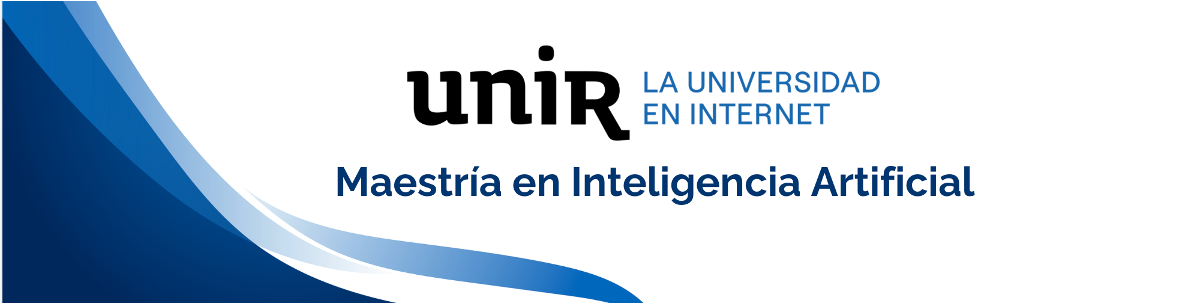

In [ ]:
import numpy as np
import pandas as pd

def generate_baseline(n=2000, seed=42, base_level=1.0, noise=0.05, dist="lognormal"):
    rng = np.random.default_rng(seed)
    t = pd.date_range("2026-01-01", periods=n, freq="H")

    if dist == "lognormal":
        # lognormal around base_level
        mu = np.log(base_level) - 0.5*(noise**2)
        sco = rng.lognormal(mean=mu, sigma=noise, size=n)
    else:
        sco = rng.normal(loc=base_level, scale=noise, size=n)
        sco = np.clip(sco, 0, None)

    df = pd.DataFrame({"timestamp": t, "sco": sco})
    df["label"] = 0
    df["drift_type"] = "none"
    return df

def inject_linear_drift(df, start, length, slope=0.0005):
    idx = np.arange(start, min(start+length, len(df)))
    df.loc[idx, "sco"] = df.loc[idx, "sco"].values + slope * np.arange(len(idx))
    df.loc[idx, "label"] = 1
    df.loc[idx, "drift_type"] = "linear"
    return df

def inject_step_drift(df, start, length, step=0.15):
    idx = np.arange(start, min(start+length, len(df)))
    df.loc[idx, "sco"] = df.loc[idx, "sco"].values + step
    df.loc[idx, "label"] = 1
    df.loc[idx, "drift_type"] = "step"
    return df

def inject_random_drift(df, start, length, extra_noise=0.12, seed=123):
    rng = np.random.default_rng(seed)
    idx = np.arange(start, min(start+length, len(df)))
    df.loc[idx, "sco"] = df.loc[idx, "sco"].values + rng.normal(0, extra_noise, size=len(idx))
    df.loc[idx, "label"] = 1
    df.loc[idx, "drift_type"] = "random"
    return df

def inject_outliers(df, n_outliers=15, magnitude=0.5, seed=7):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=n_outliers, replace=False)
    signs = rng.choice([-1, 1], size=n_outliers)
    df.loc[idx, "sco"] = np.clip(df.loc[idx, "sco"].values + signs*magnitude, 0, None)
    df.loc[idx, "label"] = 1
    df.loc[idx, "drift_type"] = "outlier"
    return df

# Ejemplo de uso
df = generate_baseline(n=2000, base_level=1.0, noise=0.06, dist="lognormal")
df = inject_linear_drift(df, start=500, length=250, slope=0.001)
df = inject_step_drift(df, start=1100, length=180, step=0.20)
df = inject_random_drift(df, start=1500, length=250, extra_noise=0.15)
df = inject_outliers(df, n_outliers=12, magnitude=0.6)

df.head(), df["drift_type"].value_counts()